In [1]:
import os, sys
from pathlib import Path
from pathlib import Path
from colorama import Fore, Back, Style

import torch

if torch.cuda.is_available():
    device = 'cuda'
    print(f'using cuda device: {torch.cuda.get_device_name()}')
else:
    device = 'cpu'


using cuda device: NVIDIA GeForce RTX 2060


In [2]:


if Path.cwd().name == "notebooks":
    os.chdir("..")
    print(
        Fore.LIGHTGREEN_EX + Style.NORMAL
        + f"changed working directory to: {Path.cwd()}"
    )

sys.path.append(".")

changed working directory to: c:\Users\neucl\Dev\Thesis\cxr-diff-vqa


### Setup Configuration

In [3]:
import yaml, argparse

DATA_ROOT = 'E:/MIMIC-CXR-JPG-512x512/'

config_path = 'configs/clinicalbert_resnet.yaml'

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

args = argparse.Namespace(**config)

In [4]:
print(Fore.LIGHTGREEN_EX + Back.BLACK + 'loaded arguments')

loaded arguments


### Load Dataset

In [5]:
import json
import pandas as pd

print(
    Fore.LIGHTBLUE_EX + Back.BLACK + Style.BRIGHT + f"Loading raw CSVs for verification"
)
df_pairs = pd.read_csv(args.train_pairs_csv)
df_meta = pd.read_csv(args.train_meta_csv)

with open(args.keyinfo_json, "r") as f:
    keyinfo = json.load(f)

    if isinstance(keyinfo, list):
        keyinfo_dict = {str(item.get("study_id")): item for item in keyinfo}
    else:
        keyinfo_dict = keyinfo

print(
    Fore.LIGHTGREEN_EX
    + Back.BLACK
    + Style.BRIGHT
    + f"Raw Pairs loaded: {len(df_pairs)} rows"
)
print(
    Fore.LIGHTGREEN_EX
    + Back.BLACK
    + Style.BRIGHT
    + f"Raw Meta loaded: {len(df_meta)} rows"
)
print(
    Fore.LIGHTGREEN_EX
    + Back.BLACK
    + Style.BRIGHT
    + f"Raw JSON loaded: {len(keyinfo_dict)} entries"
)

Loading raw CSVs for verification
Raw Pairs loaded: 560563 rows
Raw Meta loaded: 222750 rows
Raw JSON loaded: 227835 entries


### Initialize dataset class

We turn off caching to ensure we test the actual logic, or load the existing cache.
We use a unique split to avoid overwriting our real cache

In [6]:
from lib.dataset import DiffVQADataset

dataset = DiffVQADataset(
    data_root=args.data_root,
    pairs_csv=args.train_pairs_csv,
    meta_csv=args.train_meta_csv,
    split="train_verify",
    max_ans_len=args.max_ans_len,
)

vocab = dataset.itos

print(
    Fore.LIGHTGREEN_EX
    + Back.BLACK
    + Style.BRIGHT
    + f"dataset initialized with {len(dataset)} samples"
)

--- Loaded 545937 samples for split: 'train_verify' from E:/MIMIC-CXR-JPG-512x512/mimic_pair_questions_train.csv ---
dataset initialized with 545937 samples


### Inspect a specific sample

Let's get metadata IDs from the dataset output
We have to adjust the keys if our dataset returns them differently.

In [7]:
idx = 0
sample = dataset[idx]

print(Fore.LIGHTMAGENTA_EX + Back.BLACK + Style.BRIGHT + f'datatype of sample: {type(sample)}')
print(Fore.LIGHTMAGENTA_EX + Back.BLACK + Style.BRIGHT + f'keys in sample: {sample.keys()}')

datatype of sample: <class 'dict'>
keys in sample: dict_keys(['img_cur', 'img_ref', 'question', 'answer_id', 'answer_ids', 'meta'])


In [8]:
print(sample['answer_ids'])

tensor([ 1, 15,  2,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0,  0,  0,  0,  0,  0,  0,  0,  0])


In [9]:
if "meta" in sample:
    subj_id, study_id, ref_id = sample["meta"]
else:
    print(
        Fore.LIGHTRED_EX
        + Back.BLACK
        + Style.BRIGHT
        + f"dataset did not return metadata ID"
    )
    subj_id, study_id, ref_id = None, None, None

print(
    Fore.LIGHTMAGENTA_EX + Back.BLACK + Style.BRIGHT + f"dataset study id: {study_id}"
)
print(Fore.LIGHTMAGENTA_EX + Back.BLACK + Style.BRIGHT + f"dataset ref id: {ref_id}")

dataset study id: 55088298
dataset ref id: 54989200


### Compare with Raw CSVs

Let's find this specific pair in raw pairs csv

In [10]:
raw_row = df_pairs[
    (df_pairs['study_id'].astype(str) == str(study_id)) & 
    (df_pairs['ref_id'].astype(str) == str(ref_id))
]

if not raw_row.empty:
    print("\n✅ Match found in mimic_pair_questions.csv!")
    raw_q = raw_row.iloc[0]['question']
    raw_a = raw_row.iloc[0]['answer']
    
    print(f"Raw Question: '{raw_q}'")
    print(f"DS Question:  '{sample['question']}'")
    
    # Decode the answer tensor
    ans_ids = sample['answer_ids'].tolist()
    decoded_ans = " ".join([vocab[i] for i in ans_ids if i > 2]) # Skip pad/start/end
    
    print(f"Raw Answer:   '{raw_a}'")
    print(f"DS Decoded:   '{decoded_ans}'")
else:
    print("\n❌ NO MATCH found in pairs CSV! Check splitting logic.")


✅ Match found in mimic_pair_questions.csv!
Raw Question: 'what abnormalities are seen in the soft tissues?'
DS Question:  'what abnormalities are seen in the soft tissues?'
Raw Answer:   'atelectasis'
DS Decoded:   'atelectasis'


### Check Image Paths (MIMIC_ALL)

Let's check if these IDs exists in the meta CSV

In [11]:
meta_study = df_meta[df_meta['study_id'].astype(str) == str(study_id)]
meta_ref = df_meta[df_meta['study_id'].astype(str) == str(ref_id)]

if not meta_study.empty and not meta_ref.empty:
    print("\n✅ Both Study and Ref IDs found in mimic_all.csv")
else:
    print("\n❌ IDs missing from mimic_all.csv")


✅ Both Study and Ref IDs found in mimic_all.csv


### Check Disease JSON

In [12]:
if str(study_id) in keyinfo_dict:
    print("\n✅ Study ID found in all_diseases.json")
    print(f"Disease Info: {keyinfo_dict[str(study_id)].get('entity', 'No Entity Key')}")
else:
    print("\n⚠️ Study ID NOT found in all_diseases.json (This might be expected if JSON is subset)")


✅ Study ID found in all_diseases.json
Disease Info: {'pneumothorax': {'entity_name': 'pneumothorax', 'location': ['left'], 'type': None, 'level': ['minimal'], 'post_location': None, 'location2': None, 'type2': None, 'level2': None, 'post_location2': None}, 'atelectasis': {'entity_name': 'atelectasis', 'location': ['left', 'basal'], 'type': None, 'level': ['mild'], 'post_location': 'the soft tissues', 'location2': None, 'type2': None, 'level2': None, 'post_location2': None}}


In [13]:
if 'meta' in sample:
    subj_id, study_id, ref_id = sample['meta']
    
    # Look up the paths using the dataset's internal map
    # Note: We cast to string because IDs in CSV might be ints
    ref_path = dataset.study_to_path.get(str(ref_id), "Path Not Found")
    cur_path = dataset.study_to_path.get(str(study_id), "Path Not Found")
    
    print(f"\n=== File Paths for Index {idx} ===")
    print(f"Reference Image (ID: {ref_id}):\n -> {ref_path}")
    print(f"Current Image   (ID: {study_id}):\n -> {cur_path}")
else:
    print("\nCould not retrieve paths: Metadata missing from sample.")


=== File Paths for Index 0 ===
Reference Image (ID: 54989200):
 -> E:\MIMIC-CXR-JPG-512x512\p18\p18936629\s54989200\15a2bf67-fed90014-2fd19f30-0c9d8e9b-321b466e.jpg
Current Image   (ID: 55088298):
 -> E:\MIMIC-CXR-JPG-512x512\p18\p18936629\s55088298\61976388-5e534624-f6465079-76ea9caf-116f9938.jpg


### Visualize Images


Visualizing Loaded Images...


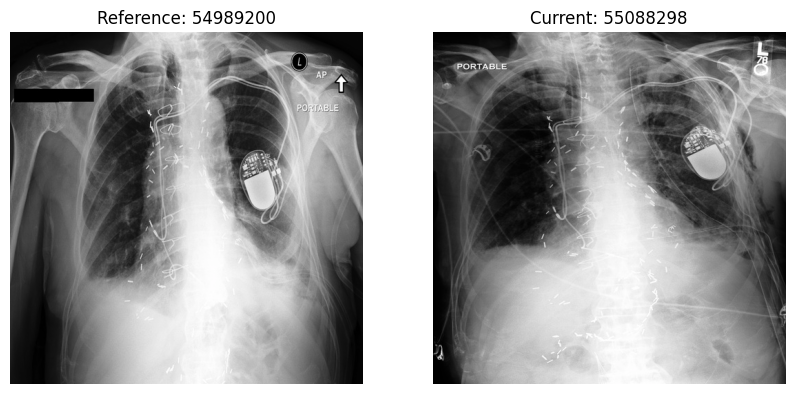

In [14]:
from matplotlib import pyplot as plt
import torch

print("\nVisualizing Loaded Images...")
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

def denorm(tensor):
    tensor = tensor.clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    tensor = tensor * std + mean
    return tensor.permute(1, 2, 0).clamp(0, 1)

ax[0].imshow(denorm(sample['img_ref']))
ax[0].set_title(f"Reference: {ref_id}")
ax[0].axis('off')

ax[1].imshow(denorm(sample['img_cur']))
ax[1].set_title(f"Current: {study_id}")
ax[1].axis('off')

plt.show()